In [ ]:
import pandas as pd

raw_total = pd.read_hdf('tesla_preprocessed.h5', key='tesla_price')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = raw_total[['open-close', 'low-high', 'is_quarter_end', 'Open', 'Close', 'High', 'Low']]
target = raw_total[['target', 'next_open',  'next_close', 'next_high', 'next_low']].values

scaler = StandardScaler()
features = scaler.fit_transform(features)
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [ ]:
x_train.shape, y_train.shape

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
print("XLA JIT enabled by default:", tf.config.optimizer.get_jit())
print("GPU devices:", tf.config.list_physical_devices('GPU'))

In [ ]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("CUDA built:", tf.sysconfig.get_build_info()["cuda_version"])
print("cuDNN built:", tf.sysconfig.get_build_info()["cudnn_version"])

In [ ]:
# -----------------------------
# 2. Scale the data
# -----------------------------
scaler_X = StandardScaler()
scaler_y = StandardScaler()

x_train = scaler_X.fit_transform(x_train)
x_test = scaler_X.transform(x_test)

y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)


In [ ]:
def custom_loss(y_pred, y_true):
    loss = ( y_pred[0] - y_true[0])*0.7
    loss += tf.reduce_mean(tf.square(y_pred[1:] - y_true[1:]))*0.3

    return tf.square(loss)*10

In [ ]:
# -----------------------------
# 3. Build the model function
# -----------------------------
def build_model(input_dim, output_dim, units=64, layers=2, dropout_rate=0.1, learning_rate=0.001):
    model = Sequential()
    model.add(Dense(units, activation='relu', input_shape=(input_dim,)))
    
    for _ in range(layers - 1):
        model.add(Dense(units, activation='relu'))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    
    # Output layer for regression
    model.add(Dense(output_dim, activation='linear'))
    
    # Compile
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model


In [ ]:
# -----------------------------
# 4. Hyperparameters
# -----------------------------
input_dim = x_train.shape[1]
output_dim = y_train.shape[1] if len(y_train.shape) > 1 else 1

units = 64          # neurons per layer
layers = 3          # hidden layers
dropout_rate = 0.1
learning_rate = 0.001
batch_size = 32
epochs = 200

In [ ]:
# -----------------------------
# 5. Callbacks
# -----------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True)


In [ ]:
import subprocess
import os

print("=== TensorFlow GPU Setup Check ===")
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Devices: {tf.config.list_physical_devices('GPU')}")

# Check CUDA
try:
    nvcc_result = subprocess.run(['nvcc', '--version'], capture_output=True, text=True)
    if nvcc_result.returncode == 0:
        print("✓ NVCC found")
        # Extract CUDA version from nvcc output
        for line in nvcc_result.stdout.split('\n'):
            if 'release' in line:
                print(f"✓ {line.strip()}")
    else:
        print("✗ NVCC not found")
except:
    print("✗ NVCC check failed")

# Check for libdevice
cuda_paths = ['/usr/local/cuda', '/usr/local/cuda-11.8', '/opt/cuda']
libdevice_found = False

for path in cuda_paths:
    libdevice_path = os.path.join(path, 'nvvm', 'libdevice', 'libdevice.10.bc')
    if os.path.exists(libdevice_path):
        print(f"✓ Found libdevice at: {libdevice_path}")
        os.environ['XLA_FLAGS'] = f'--xla_gpu_cuda_data_dir={path}'
        libdevice_found = True
        break

if not libdevice_found:
    print("✗ libdevice.10.bc not found in standard locations")
    print("→ Using CPU mode for now")
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Now run your model
model = build_model(input_dim, output_dim, units, layers, dropout_rate, learning_rate)
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=2
)

In [ ]:

# -----------------------------
# 7. Make predictions (scaled back)
# -----------------------------
y_pred_scaled = model.predict(x_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

In [ ]:
import matplotlib.pyplot as plt

# Plot MSE loss and MAE metric
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# MAE metric
plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.show()

In [ ]:
for t, p in zip(y_true, y_pred):
    print('📈', t)
    print('📉', p)

CNN Method

In [211]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dropout, Dense

def build_cnn_model(input_dim, output_dim, dropout_rate, learning_rate):
    model = Sequential()

    # Input shape must be (timesteps, features)
    model.add(Conv1D(32, kernel_size=3, activation='relu', padding='same', input_shape=(input_dim, 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dropout(dropout_rate))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(output_dim))

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mae', metrics=['mae'])

    return model

In [ ]:
model = build_cnn_model(input_dim, output_dim, dropout_rate, learning_rate)
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/200
43/43 - 1s - loss: 0.6149 - mae: 0.6149 - val_loss: 0.2789 - val_mae: 0.2789 - 1s/epoch - 27ms/step
Epoch 2/200
43/43 - 0s - loss: 0.2933 - mae: 0.2933 - val_loss: 0.2464 - val_mae: 0.2464 - 211ms/epoch - 5ms/step
Epoch 3/200
43/43 - 0s - loss: 0.2751 - mae: 0.2751 - val_loss: 0.2522 - val_mae: 0.2522 - 214ms/epoch - 5ms/step
Epoch 4/200
43/43 - 0s - loss: 0.2669 - mae: 0.2669 - val_loss: 0.2501 - val_mae: 0.2501 - 219ms/epoch - 5ms/step
Epoch 5/200
43/43 - 0s - loss: 0.2620 - mae: 0.2620 - val_loss: 0.2439 - val_mae: 0.2439 - 234ms/epoch - 5ms/step
Epoch 6/200
43/43 - 0s - loss: 0.2573 - mae: 0.2573 - val_loss: 0.2359 - val_mae: 0.2359 - 223ms/epoch - 5ms/step
Epoch 7/200
43/43 - 0s - loss: 0.2524 - mae: 0.2524 - val_loss: 0.2336 - val_mae: 0.2336 - 232ms/epoch - 5ms/step
Epoch 8/200
43/43 - 0s - loss: 0.2513 - mae: 0.2513 - val_loss: 0.2375 - val_mae: 0.2375 - 230ms/epoch - 5ms/step
Epoch 9/200
43/43 - 0s - loss: 0.2466 - mae: 0.2466 - val_loss: 0.2356 - val_mae: 0.2356 -

In [217]:
y_pred_scaled = model.predict(x_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

11/11 [==============================] - 0s 3ms/step


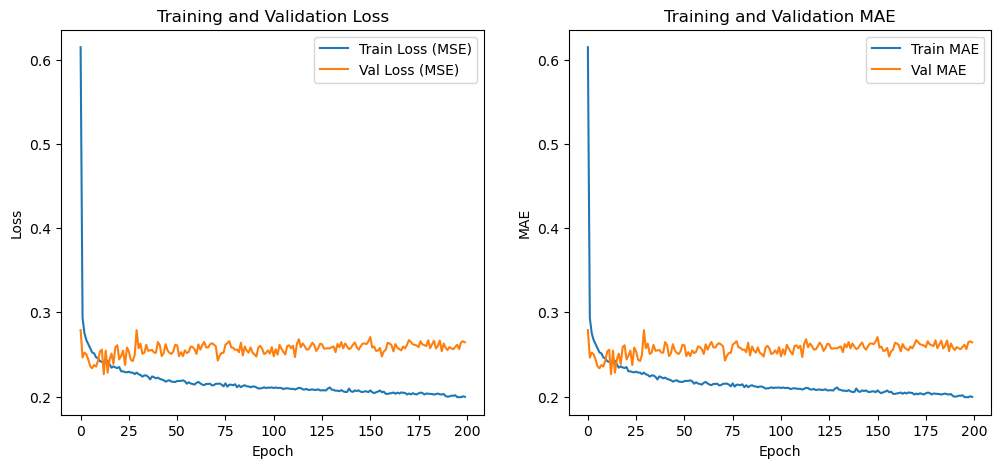

In [218]:
import matplotlib.pyplot as plt

# Plot MSE loss and MAE metric
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# MAE metric
plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.show()

In [219]:
for t, p in zip(y_true, y_pred):
    print('📈', t)
    print('📉', p)

📈 [  1.       204.470001 206.899994 209.199997 204.050003]
📉 [  0.8822433 197.77914   198.12234   201.61394   195.68788  ]
📈 [  1.       221.529999 219.740005 223.800003 217.199997]
📉 [  0.406152 213.18617  209.99336  216.5565   209.31319 ]
📈 [  0.       230.389999 226.050003 232.889999 225.169998]
📉 [1.0115095e-01 2.2340054e+02 2.2324849e+02 2.2718077e+02 2.2019051e+02]
📈 [  0.       202.699997 197.330002 203.339996 195.830002]
📉 [  0.7943041 196.5861    196.28865   199.84242   193.47647  ]
📈 [  1.       279.029999 280.980011 287.390015 278.609985]
📉 [-9.6852787e-02  2.6739438e+02  2.6795023e+02  2.7275214e+02
  2.6441910e+02]
📈 [ 1.       20.16     20.65     20.690001 20.040001]
📉 [ 0.9542317 28.990364  28.95943   30.285973  28.581955 ]
📈 [  0.       202.       195.649994 204.589996 194.529999]
📉 [  0.6916057 194.89914   193.91953   198.19926   191.84952  ]
📈 [  0.       191.       189.399994 191.889999 187.5     ]
📉 [  0.72923094 186.25378    185.92815    189.40454    182.5183    ]
